In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
from misc import fishinv

try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 788953) PSD_funcs: (3, 394476)
[TRUE] SNR: 108.515622
[TRUE] SNR - Channel 0: 50.941054
[TRUE] SNR - Channel 1: 95.814277
[TRUE] SNR - Channel 2: 0.523006
[INFO] Frequency resolution delta_f: 1.267503e-07 Hz, Number of frequency bins: 394477
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


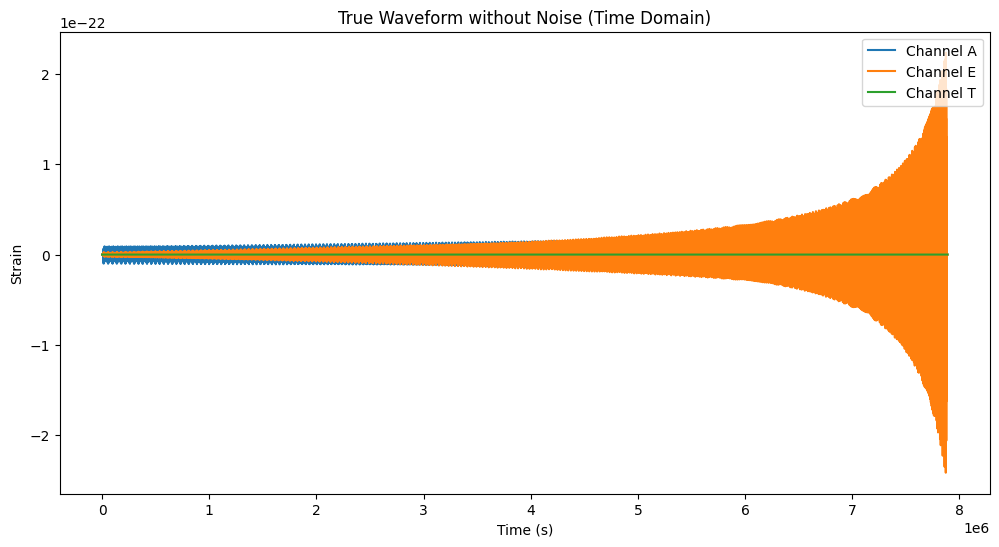

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 394476)


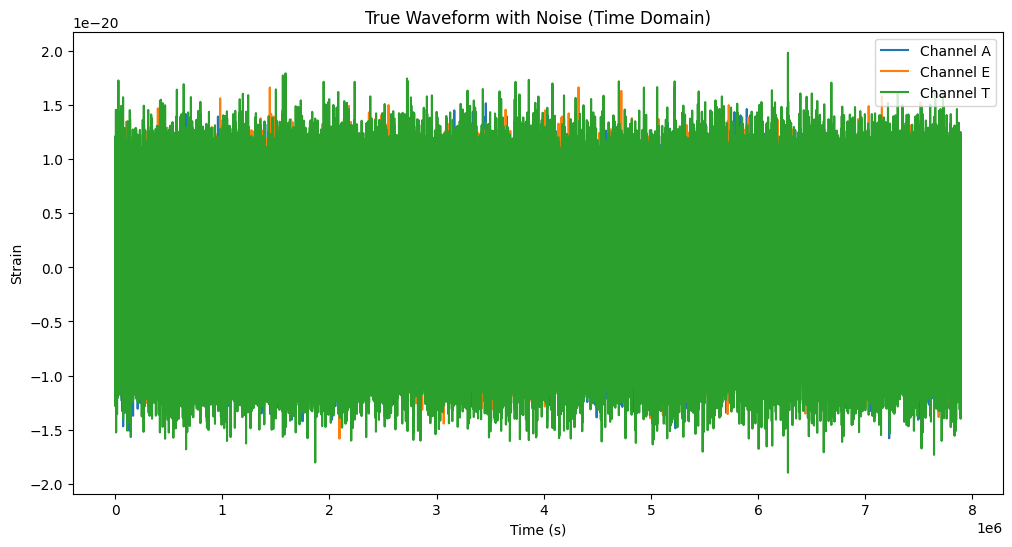

Length of PSD: 394476


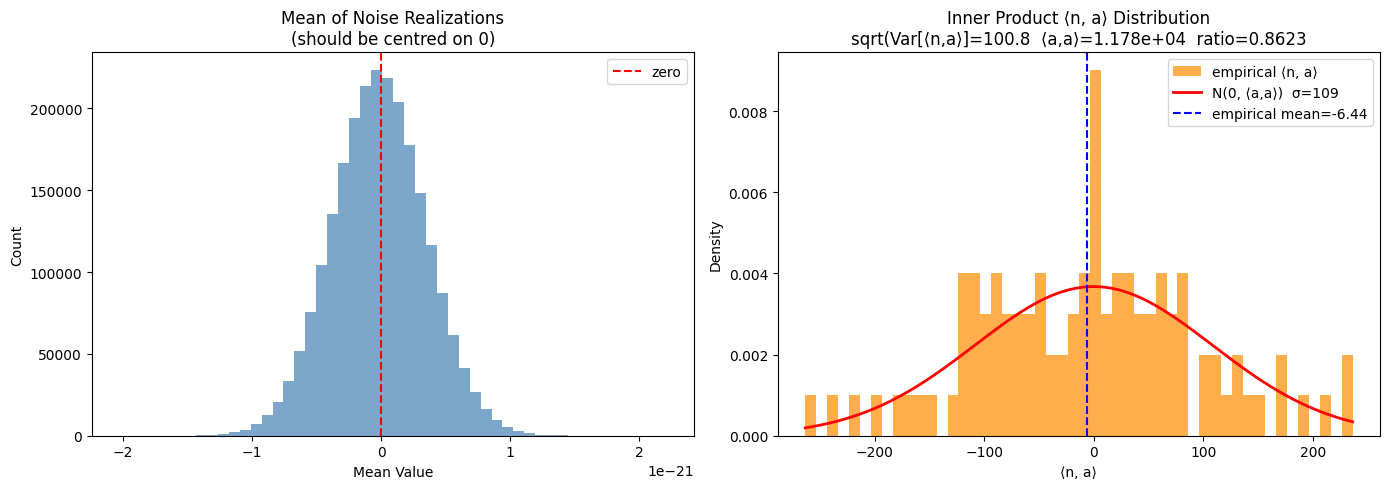

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 100
  N time samples         : 788950  |  PSD bins passed: 394475
  N (template samples)   : 788953  →  aligned to 788950
  Max |mean noise|       : 2.2122e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : -6.4383e+00           (expect ≈ 0)
  Var[⟨n, a⟩]           : 10154.4
  ⟨a, a⟩                : 11775.6
  Ratio Var/⟨a,a⟩       : 0.862332          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-3.25266847e-22,  1.92187775e-22,  2.50648700e-22, ...,
         4.56458431e-22, -4.43890482e-22,  9.32194041e-24],
       [-5.20353732e-22,  6.39705629e-22, -3.64221292e-22, ...,
         8.25885366e-23,  8.59497806e-23,  2.28084011e-23],
       [-5.99126782e-23,  1.27191807e-24,  1.42936991e-22, ...,
        -6.02353237e-22,  6.64498006e-22, -1.68851937e-22]],
      shape=(3, 788950)), 'inner_products': array([  31.11618787, -126.1228669 ,   82.86971676,   52.69674709,
         

{'m1': np.float64(1000000.0),
 'm2': np.float64(5000.0),
 'a': np.float64(0.7),
 'p0': np.float64(25.0),
 'e0': np.float64(0.25),
 'Y0': np.float64(1.0),
 'dist': np.float64(3.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 0.25,
 'chi2': 0.95,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1552bccf4a10>,
 'PSD_funcs': array([[4.26101649e-36, 1.06525447e-36, 4.73446683e-37, ...,
         1.61317874e-40, 1.61314534e-40, 1.61311193e-40],
        [4.26101649e-36, 1.06525447e-36, 4.73446683e-37, ...,
         1.61317874e-40, 1.61314534e-40, 1.61311193e-40],
        [4.25581070e-55, 1.70232428e-54, 3.83022963e-54, ...,
         5.36087803e-40, 5.36079136e-40, 5.36070468e-40]],
       shape=(3, 394476)),
 'waveform_true_fft': array([[-7.82118976e-16-

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,5e3,0.70, 25.0,  0.25,  1.00000000e+00,3, 
                    np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01,   5.00000000e-01,  4.00000000e-01])

signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 3,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 0.25

chi2 = 0.95 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

# Overlap with Noise and With True Signal Without Noise

In [3]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


In [4]:
use_gpu = True
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": ch} for ch in channels]

sef = StableEMRIFisher(waveform_class=SuperKludgeWaveform,
                       waveform_class_kwargs = dict(sum_kwargs=dict(pad_output=False, odd_len=True)),
                       waveform_generator = GenerateEMRIWaveform,
                       waveform_generator_kwargs= dict(return_list=False),
                       ResponseWrapper=ResponseWrapper,
                       ResponseWrapper_kwargs = dict(Tobs=ctx['T'],
                                                    t0=10000.0,
                                                    dt=ctx['dt'],
                                                    index_lambda=8,
                                                    index_beta=7,
                                                    flip_hx=True,
                                                    is_ecliptic_latitude=False,
                                                    remove_garbage="zero",
                                                    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
                                                    force_backend = "cuda12x" if use_gpu else "cpu",
                                                    order=20,
                                                    tdi="2nd generation",
                                                    tdi_chan="AET"),
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs=noise_kwargs,
                       channels=channels,
                       T = ctx['T'], dt = ctx['dt'],
                       stability_plot = False,
                       der_order = 6, Ndelta = 12,
                       plunge_check=True, return_derivatives=False
                       )
emri_kwargs = {"T":ctx['T'], "dt":ctx['dt']}



waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1000221.8808939782, 4999.747773291232, 0.7003948786264647, 24.99655848906371, 0.2499766455289157, np.float64(1.0), np.float64(3.0), 0.7807865861253576, 1.0162072746890254, np.float64(1.0), np.float64(1.0471975511965976), 0.9914252791409727, np.float64(0.5), 0.4069748546993725, 0.95, True, False, False, True, 0, 0)
SNR:  108.60834486141063
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1000221.8808939782, 4999.747773291232, 0.7003948786264647, 24.99655848906371, 0.2499766455289157, np.float64(1.0), np.float64(3.0), 0.7807865861253576, 1.0162072746890254, np.float64(1.0), np.float64(1.0471975511965976), 0.9914252791409727, np.float64(0.5), 0.4069748546993725, 0.95, True, False, False, True, 0, 0)
Waveform Generated. SNR: 108.60834486141063
calculating stable deltas...
Gamma_ii for m1: 142.75720880998733
Gamma_ii for m1: 142.75723169545316
Gamma_i

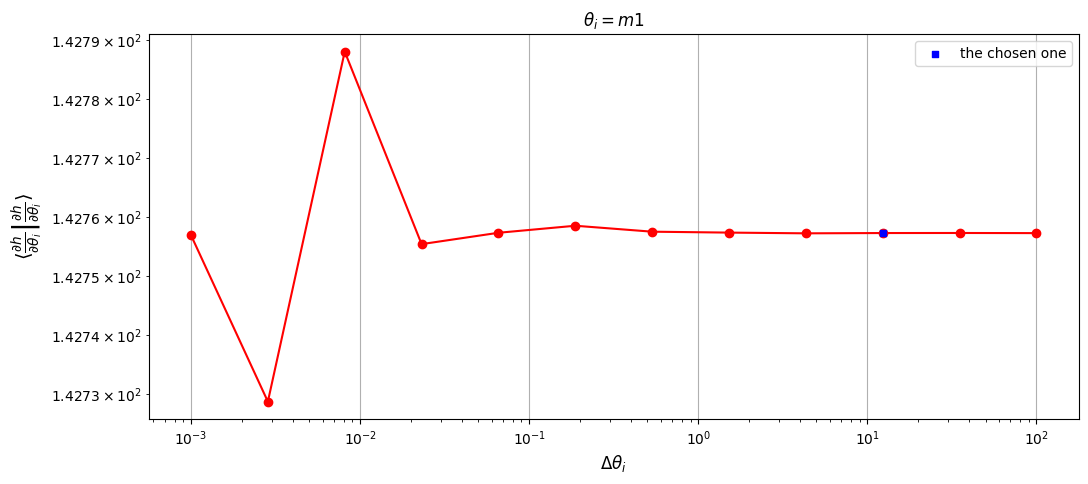

Gamma_ii for m2: 619975.8766324561
Gamma_ii for m2: 619975.8826596825
Gamma_ii for m2: 619975.8205044812
Gamma_ii for m2: 619976.0300397698
Gamma_ii for m2: 619976.6984193414
Gamma_ii for m2: 619975.7060618004
Gamma_ii for m2: 619975.2786019841
Gamma_ii for m2: 620007.3443437273
Gamma_ii for m2: 619938.0744345398
Gamma_ii for m2: 620186.8052129308
Gamma_ii for m2: 619613.1680264572
Gamma_ii for m2: 619966.1757237389
[np.float64(9.721711152471011e-09), np.float64(1.0025423456364355e-07), np.float64(3.379732094013769e-07), np.float64(1.078072084363362e-06), np.float64(1.6006393981075905e-06), np.float64(6.894788082187118e-07), np.float64(5.1718325654892465e-05), np.float64(0.00011173682024733199), np.float64(0.00040105783660716513), np.float64(0.0009257988953021907), np.float64(0.0005693983173671771)]
0


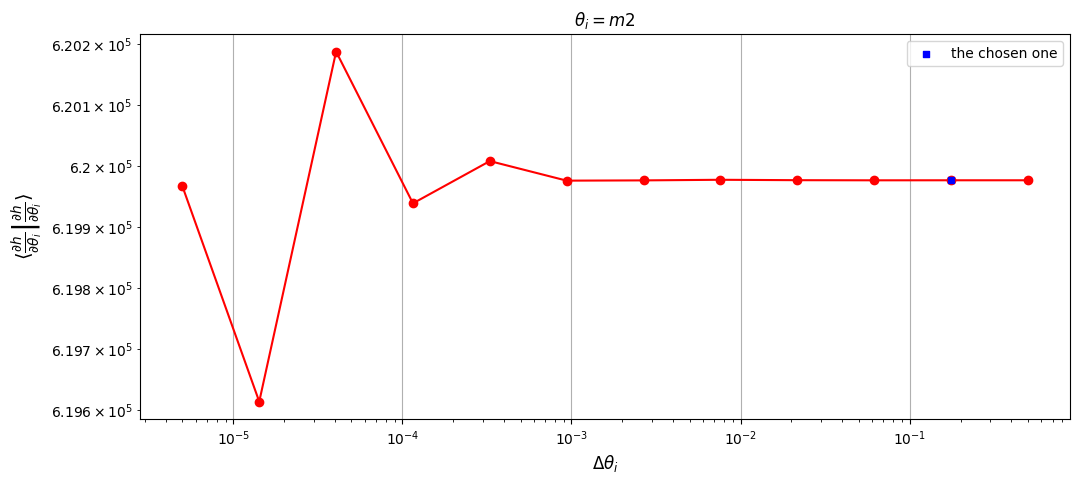

Gamma_ii for a: 322613742241.48596
Gamma_ii for a: 322613792338.31305
Gamma_ii for a: 322613154241.1904
Gamma_ii for a: 322612716273.0824
Gamma_ii for a: 322616953637.6678
Gamma_ii for a: 322600419999.82336
Gamma_ii for a: 322631094810.5766
Gamma_ii for a: 322580216361.7773
Gamma_ii for a: 321824184804.36865
Gamma_ii for a: 323470135070.2576
Gamma_ii for a: 316580439309.24536
Gamma_ii for a: 316142052495.912
[np.float64(1.5528420754828632e-07), np.float64(1.977901750846086e-06), np.float64(1.3575661650655429e-06), np.float64(1.313435186096011e-05), np.float64(5.125113552062468e-05), np.float64(9.50770438641219e-05), np.float64(0.00015772340093620516), np.float64(0.0023492067815481577), np.float64(0.0050884149336737905), np.float64(0.021762859941836788), np.float64(0.0013866766849659862)]
0


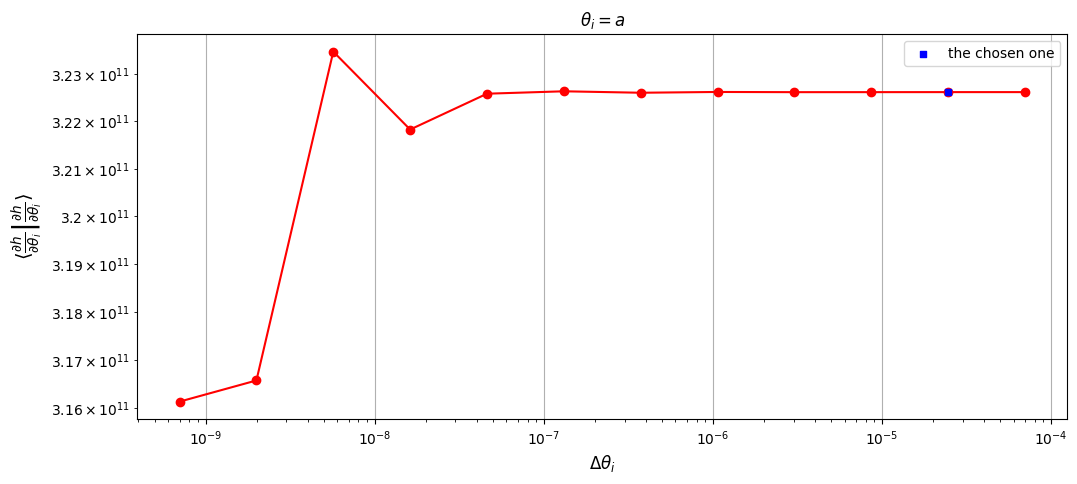

Gamma_ii for p0: 762521885399.8467
Gamma_ii for p0: 762521890591.0723
Gamma_ii for p0: 762521877376.0548
Gamma_ii for p0: 762521894804.7859
Gamma_ii for p0: 762522147996.0981
Gamma_ii for p0: 762522188590.359
Gamma_ii for p0: 762522113667.227
Gamma_ii for p0: 762520890604.1544
Gamma_ii for p0: 762523681589.204
Gamma_ii for p0: 762575061803.8529
Gamma_ii for p0: 762586233799.5781
Gamma_ii for p0: 761960984713.1321
[np.float64(6.807969253070883e-09), np.float64(1.7330673188721382e-08), np.float64(2.2856695916336292e-08), np.float64(3.3204453525873843e-07), np.float64(5.323682572346206e-08), np.float64(9.825699558754709e-08), np.float64(1.6039731995575733e-06), np.float64(3.6601945840472144e-06), np.float64(6.737725533193692e-05), np.float64(1.4650140836604632e-05), np.float64(0.0008205788734464438)]
0


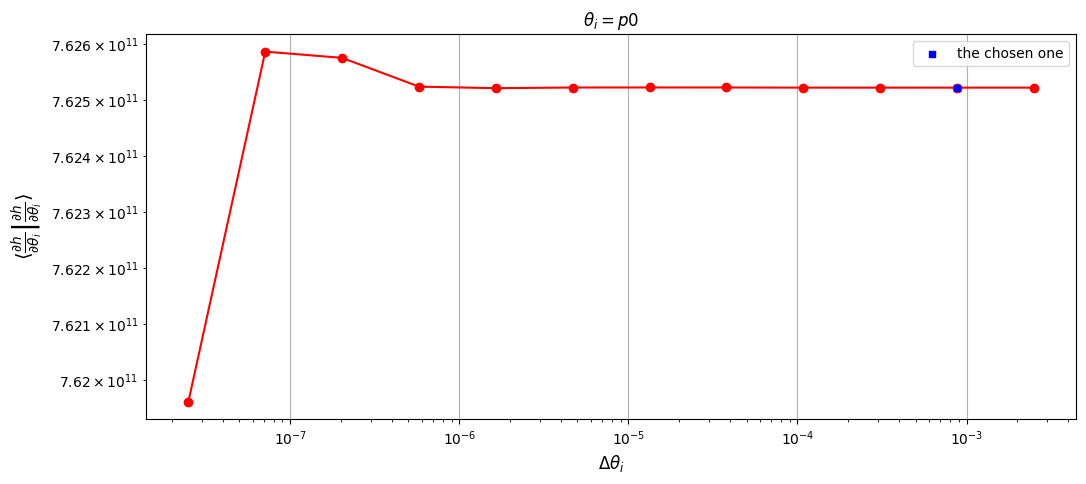

Gamma_ii for e0: 5948290161508.158
Gamma_ii for e0: 5948289264343.375
Gamma_ii for e0: 5948295011456.786
Gamma_ii for e0: 5948281894468.999
Gamma_ii for e0: 5948242556054.051
Gamma_ii for e0: 5948106643877.715
Gamma_ii for e0: 5947944561253.755
Gamma_ii for e0: 5948007492422.554
Gamma_ii for e0: 5951404715456.319
Gamma_ii for e0: 5932444272901.952
Gamma_ii for e0: 5999656014240.802
Gamma_ii for e0: 5850748008991.015
[np.float64(1.5082736284886476e-07), np.float64(9.661782746255043e-07), np.float64(2.205172522053164e-06), np.float64(6.613451717466366e-06), np.float64(2.284965359116915e-05), np.float64(2.7250190766034288e-05), np.float64(1.0580210075222517e-05), np.float64(0.0005708270897697041), np.float64(0.003196059108548925), np.float64(0.011202599145570282), np.float64(0.02545110557162193)]
0


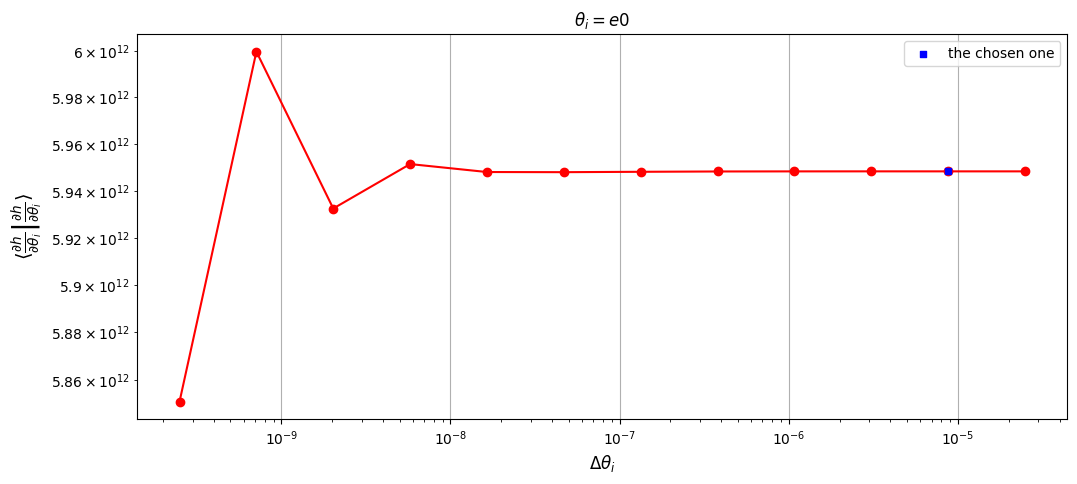

Gamma_ii for qS: 230380.05585088226
Gamma_ii for qS: 284709.84826750844
Gamma_ii for qS: 282126.86683898786
Gamma_ii for qS: 282450.772983989
Gamma_ii for qS: 282709.0753046883
Gamma_ii for qS: 1211105.828482919
Gamma_ii for qS: 7831988.342193908
Gamma_ii for qS: 60407774.02544772
Gamma_ii for qS: 484844346.07622117
Gamma_ii for qS: 5873456.388603913
Gamma_ii for qS: 5760300.027768859
Gamma_ii for qS: 8318875.0821443405
[np.float64(0.19082512511326566), np.float64(0.009155389762984566), np.float64(0.0011467702551463093), np.float64(0.0009136683016664388), np.float64(0.766569470102525), np.float64(0.8453641941780952), np.float64(0.8703480062202829), np.float64(0.8754079025272347), np.float64(81.54838616269456), np.float64(0.019644178304872584), np.float64(0.307562624647077)]
3


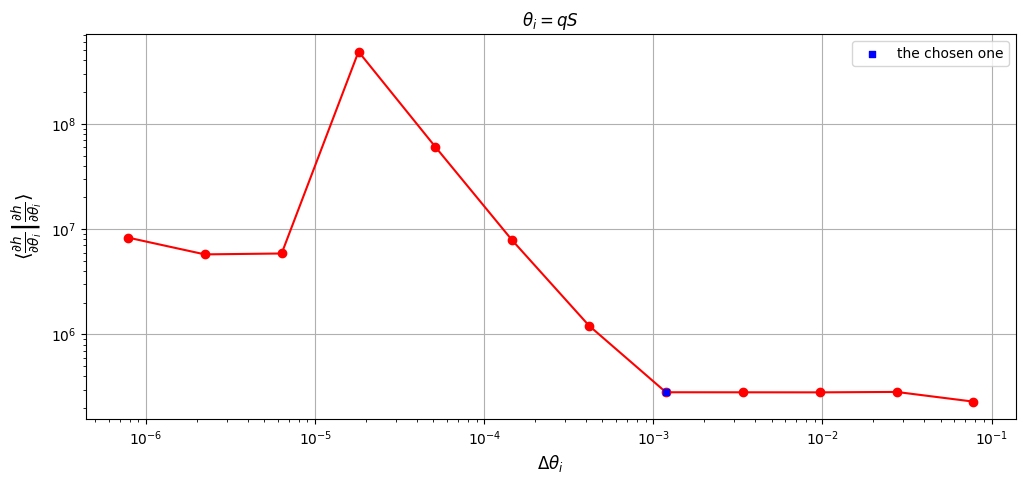

Gamma_ii for phiS: 346910.35115607514
Gamma_ii for phiS: 358143.1272942843
Gamma_ii for phiS: 358302.1634879013
Gamma_ii for phiS: 366648.7373455132
Gamma_ii for phiS: 425858.972249008
Gamma_ii for phiS: 896971.3659799912
Gamma_ii for phiS: 558663.6500599766
Gamma_ii for phiS: 407342.6152333467
Gamma_ii for phiS: 371009.3600488051
Gamma_ii for phiS: 438935.49815825094
Gamma_ii for phiS: 1216678.7863239953
Gamma_ii for phiS: 1207310.94285271
[np.float64(0.03136393045727566), np.float64(0.0004438605451580189), np.float64(0.022764496389759626), np.float64(0.13903719015428764), np.float64(0.5252256778746406), np.float64(0.6055660071738956), np.float64(0.37148343720419597), np.float64(0.09793083166355186), np.float64(0.15475198154275555), np.float64(0.639234691118084), np.float64(0.007759263284030619)]
1


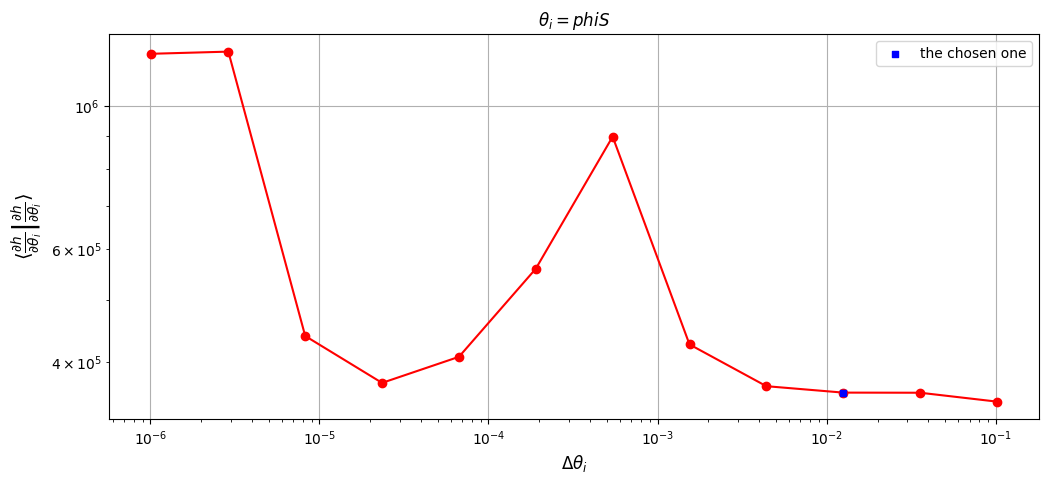

stable deltas: {'m1': 12.331202845787514, 'm2': 0.1755507305474068, 'a': 2.459220708519856e-05, 'p0': 0.0008776770955062559, 'e0': 8.777159315279555e-06, 'qS': 0.001186726185672917, 'phiS': 0.012528278251976733, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 42.160245418548584 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.1072306632995605 seconds


In [5]:
x_best_fit_1PA =  [1000221.8808939782, 4999.747773291232, 0.7003948786264647, 24.99655848906371, 0.2499766455289157,
                    0.7807865861253576, 1.0162072746890254, 0.9914252791409727, 0.4069748546993725]
add_kwargs_1PA = {'chi2': 0.95,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_1PA['chi2'],add_kwargs_1PA['evolve_1PA'],add_kwargs_1PA['evolve_primary'],
                    add_kwargs_1PA['evolve_2PA'], add_kwargs_1PA['deviation_included'],add_kwargs_1PA['dev_1'],add_kwargs_1PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_1PA,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)

Covariance_fit_1PA = fishinv(m1, Fisher, index_of_M=0)


waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (999074.3200779095, 4998.755914642618, 0.6994312870114014, 25.00935551126446, 0.2500845684812003, np.float64(1.0), np.float64(3.0), 0.7817720111109617, 1.005068126143674, np.float64(1.0), np.float64(1.0471975511965976), 0.9829643128847826, np.float64(0.5), 0.3506642434524663, 0.95, False, False, False, True, 0, 0)
SNR:  108.38685639535802
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (999074.3200779095, 4998.755914642618, 0.6994312870114014, 25.00935551126446, 0.2500845684812003, np.float64(1.0), np.float64(3.0), 0.7817720111109617, 1.005068126143674, np.float64(1.0), np.float64(1.0471975511965976), 0.9829643128847826, np.float64(0.5), 0.3506642434524663, 0.95, True, False, False, True, 0.0, 0.0)
Waveform Generated. SNR: 108.84240844234293
calculating stable deltas...
Gamma_ii for m1: 144.2815863210458
Gamma_ii for m1: 144.28157864783228
Gamma_i

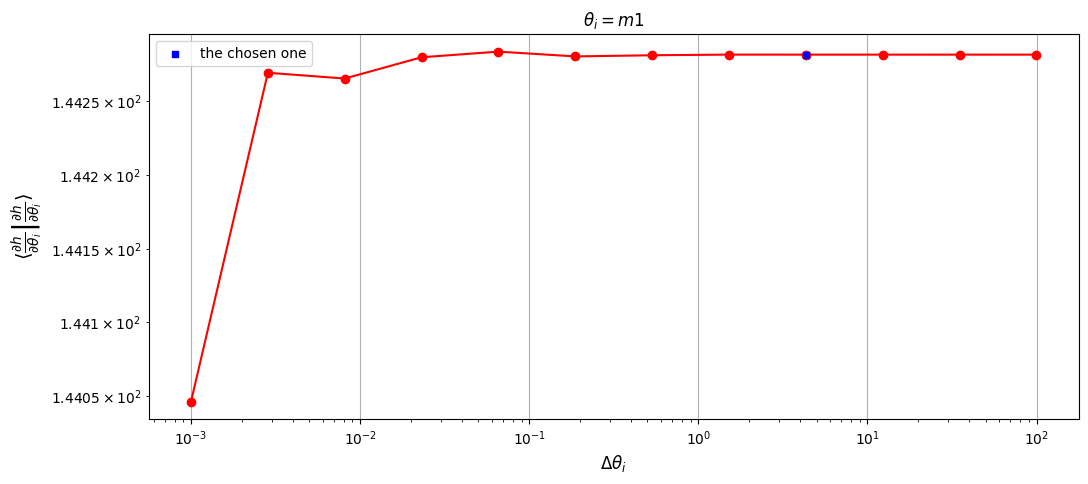

Gamma_ii for m2: 626851.5522141973
Gamma_ii for m2: 626851.543528745
Gamma_ii for m2: 626851.7957543781
Gamma_ii for m2: 626851.516928287
Gamma_ii for m2: 626851.1530407513
Gamma_ii for m2: 626851.1870036589
Gamma_ii for m2: 626855.8700531106
Gamma_ii for m2: 626864.2191107129
Gamma_ii for m2: 626836.145720369
Gamma_ii for m2: 626584.9238886415
Gamma_ii for m2: 626685.5024879623
Gamma_ii for m2: 623960.8348351186
[np.float64(1.3855676814672245e-08), np.float64(4.023688451350896e-07), np.float64(4.448040461887949e-07), np.float64(5.805007039961745e-07), np.float64(5.418017578425589e-08), np.float64(7.470695698192695e-06), np.float64(1.3318765607765372e-05), np.float64(4.478585119188149e-05), np.float64(0.0004009382003134049), np.float64(0.00016049294091122936), np.float64(0.004366728648222975)]
0


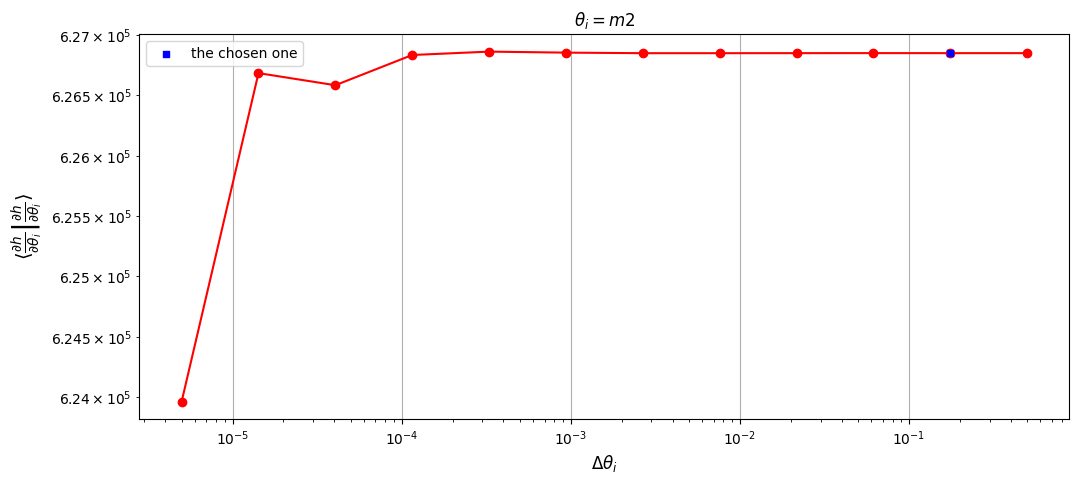

Gamma_ii for a: 325855024540.73126
Gamma_ii for a: 325855239096.4183
Gamma_ii for a: 325854160375.4325
Gamma_ii for a: 325853533173.7839
Gamma_ii for a: 325865189495.4395
Gamma_ii for a: 325846747121.1218
Gamma_ii for a: 325975831284.6783
Gamma_ii for a: 325919358205.8216
Gamma_ii for a: 325944067269.26416
Gamma_ii for a: 325635872531.6537
Gamma_ii for a: 327909610359.1828
Gamma_ii for a: 303312124084.9945
[np.float64(6.584386600831458e-07), np.float64(3.3104410406666635e-06), np.float64(1.924796219061117e-06), np.float64(3.5770379995752134e-05), np.float64(5.659830727367273e-05), np.float64(0.0003959930496924691), np.float64(0.00017327316538536533), np.float64(7.580767967208812e-05), np.float64(0.000946439761732686), np.float64(0.006934038392587904), np.float64(0.08109628439150542)]
0


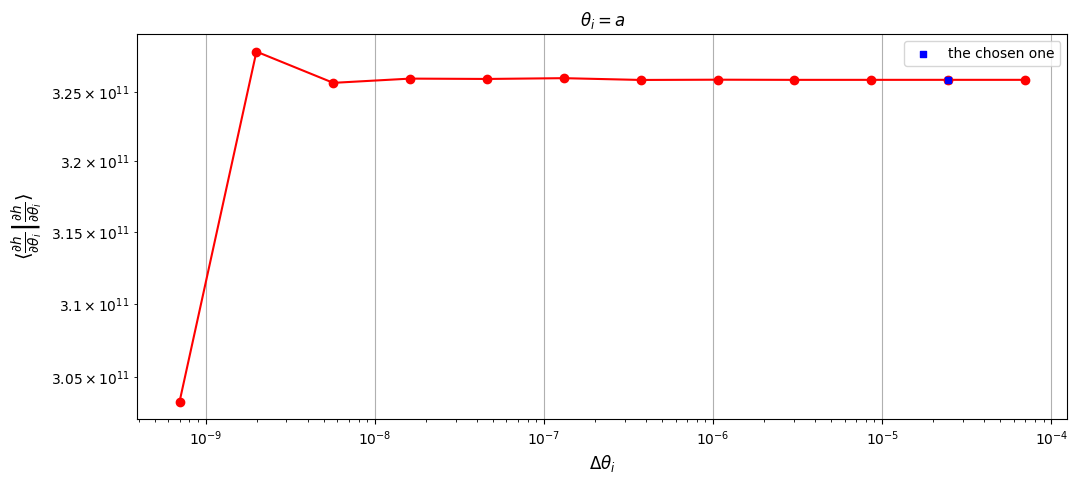

Gamma_ii for p0: 768521792883.6947
Gamma_ii for p0: 768521796546.9906
Gamma_ii for p0: 768521787668.6772
Gamma_ii for p0: 768521757934.722
Gamma_ii for p0: 768521627832.1409
Gamma_ii for p0: 768521113579.8118
Gamma_ii for p0: 768517423183.0116
Gamma_ii for p0: 768525687978.418
Gamma_ii for p0: 768515311706.2316
Gamma_ii for p0: 768563128613.4343
Gamma_ii for p0: 768047369185.6488
Gamma_ii for p0: 768772576824.3313
[np.float64(4.766677945761439e-09), np.float64(1.1552454981692436e-08), np.float64(3.8689802719574924e-08), np.float64(1.6928942070733055e-07), np.float64(6.691453494441397e-07), np.float64(4.801968945461477e-06), np.float64(1.0754091288883717e-05), np.float64(1.3501711713933612e-05), np.float64(6.22159786523006e-05), np.float64(0.0006715203364766106), np.float64(0.0009433318260105017)]
0


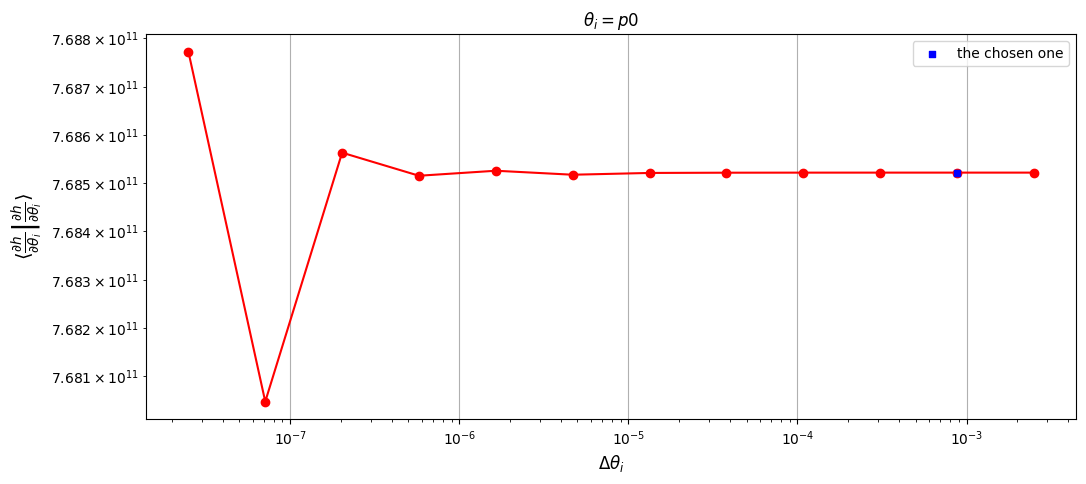

Gamma_ii for e0: 5985196715724.992
Gamma_ii for e0: 5985193979736.854
Gamma_ii for e0: 5985199498896.422
Gamma_ii for e0: 5985208950358.075
Gamma_ii for e0: 5985213030415.382
Gamma_ii for e0: 5984442152905.766
Gamma_ii for e0: 5985546368299.473
Gamma_ii for e0: 5986153808561.795
Gamma_ii for e0: 5986454747388.652
Gamma_ii for e0: 5985171123235.597
Gamma_ii for e0: 5967475969398.674
Gamma_ii for e0: 6023494146835.629
[np.float64(4.57126059395015e-07), np.float64(9.22134603763337e-07), np.float64(1.579136456506646e-06), np.float64(6.816895716003385e-07), np.float64(0.00012881359530593988), np.float64(0.00018448030067148993), np.float64(0.0001014742156229705), np.float64(5.026995768884651e-05), np.float64(0.00021446741064301165), np.float64(0.002965266040058464), np.float64(0.009299947185369735)]
0


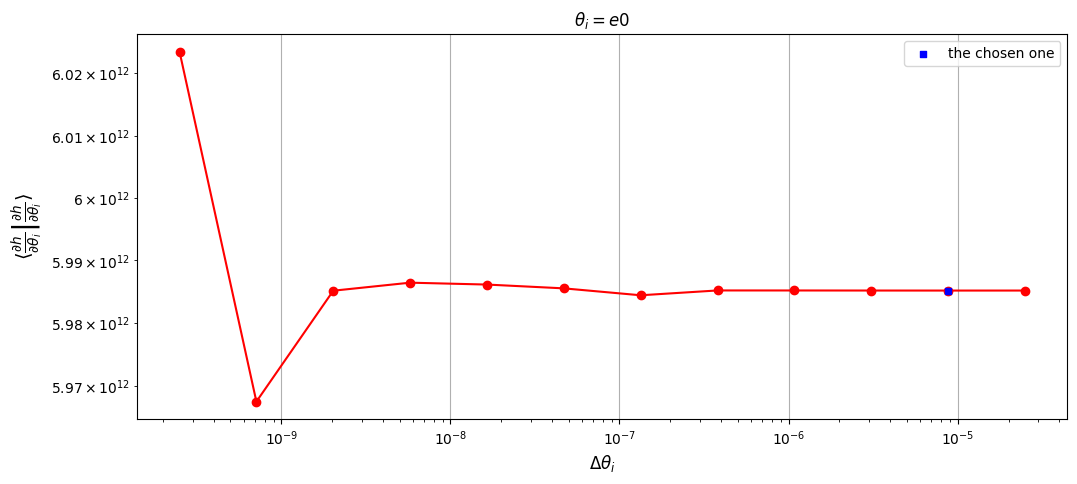

Gamma_ii for qS: 274562.9200884102
Gamma_ii for qS: 325873.2443154897
Gamma_ii for qS: 329371.2535258218
Gamma_ii for qS: 322239.302547308
Gamma_ii for qS: 323629.4546650652
Gamma_ii for qS: 327435.45519588434
Gamma_ii for qS: 343933.77621656755
Gamma_ii for qS: 334399.23902474047
Gamma_ii for qS: 735423.5297328851
Gamma_ii for qS: 11365132.53144732
Gamma_ii for qS: 14716928.106595226
Gamma_ii for qS: 28832381.32342626
[np.float64(0.15745485437093487), np.float64(0.0106202626151703), np.float64(0.02213246777204269), np.float64(0.004295505547218986), np.float64(0.011623666498004082), np.float64(0.047969470175835784), np.float64(0.0285124368692767), np.float64(0.5452970628418723), np.float64(0.9352912491167201), np.float64(0.2277510327475091), np.float64(0.4895694552070263)]
3


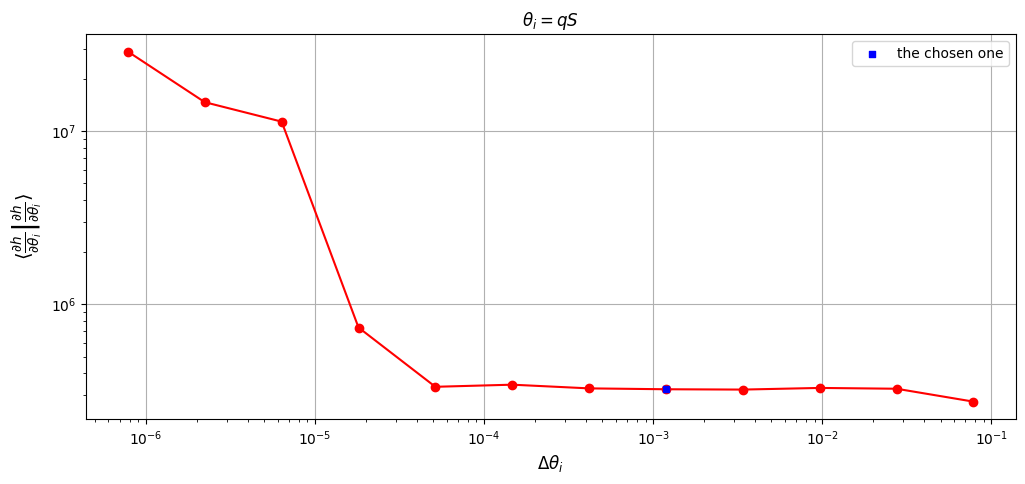

Gamma_ii for phiS: 341273.0649684541
Gamma_ii for phiS: 350998.47217862826
Gamma_ii for phiS: 350474.34826749883
Gamma_ii for phiS: 350483.8551785102
Gamma_ii for phiS: 350649.53350463044
Gamma_ii for phiS: 350598.04874416033
Gamma_ii for phiS: 351433.4267232196
Gamma_ii for phiS: 356788.7945732453
Gamma_ii for phiS: 366792.1374798886
Gamma_ii for phiS: 10578353.320080733
Gamma_ii for phiS: 6354666.53080124
Gamma_ii for phiS: 29074675.6914137
[np.float64(0.027707833455254276), np.float64(0.001495470107071547), np.float64(2.7125103969517866e-05), np.float64(0.0004724897947655847), np.float64(0.00014684839420676843), np.float64(0.002377058969172046), np.float64(0.01500991043295292), np.float64(0.02727251182474388), np.float64(0.9653261593386551), np.float64(0.6646590767284434), np.float64(0.7814363744501579)]
2


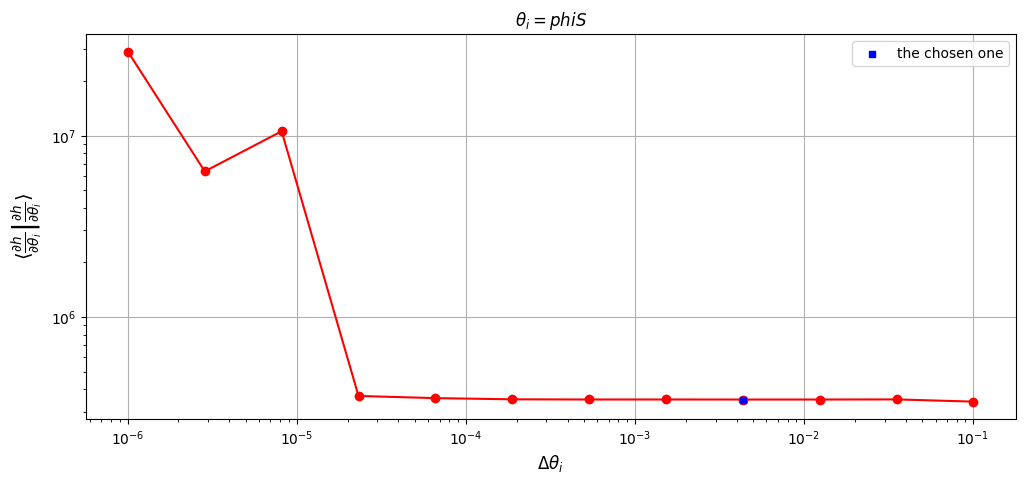

stable deltas: {'m1': 4.324754233677639, 'm2': 0.17551590448852158, 'a': 2.4558373536058873e-05, 'p0': 0.0008781264234919944, 'e0': 8.780948697059491e-06, 'qS': 0.0011882239440299549, 'phiS': 0.004350699989301443, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 35.245192766189575 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.6380908489227295 seconds


In [6]:
x_best_fit_0PA =  [999074.3200779095, 4998.755914642618, 0.6994312870114014, 25.00935551126446,
                    0.2500845684812003, 0.7817720111109617, 1.005068126143674, 0.9829643128847826, 0.3506642434524663]
add_kwargs_0PA = {'chi2': 0.95,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA['chi2'],add_kwargs_0PA['evolve_1PA'],add_kwargs_0PA['evolve_primary'],
                    add_kwargs_0PA['evolve_2PA'], add_kwargs_0PA['deviation_included'],add_kwargs_0PA['dev_1'],add_kwargs_0PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)

Covariance_fit_0PA = fishinv(m1, Fisher, index_of_M=0)

waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1002570.1299598757, 4950.1983637714975, 0.7050753237616896, 24.955671106332613, 0.24972703426218926, np.float64(1.0), np.float64(3.0), 0.7817115297347373, 1.0060200227981309, np.float64(1.0), np.float64(1.0471975511965976), 0.9601402852592612, np.float64(0.5), 0.46323805827618125, 0.95, False, False, False, True, 1.7990568266070708, 2.0480302502976233)
SNR:  107.45102789687732
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1002570.1299598757, 4950.1983637714975, 0.7050753237616896, 24.955671106332613, 0.24972703426218926, np.float64(1.0), np.float64(3.0), 0.7817115297347373, 1.0060200227981309, np.float64(1.0), np.float64(1.0471975511965976), 0.9601402852592612, np.float64(0.5), 0.46323805827618125, 0.95, False, False, False, True, 1.7990568266070708, 2.0480302502976233)
Waveform Generated. SNR: 107.45102789687732
calculating stable deltas...
G

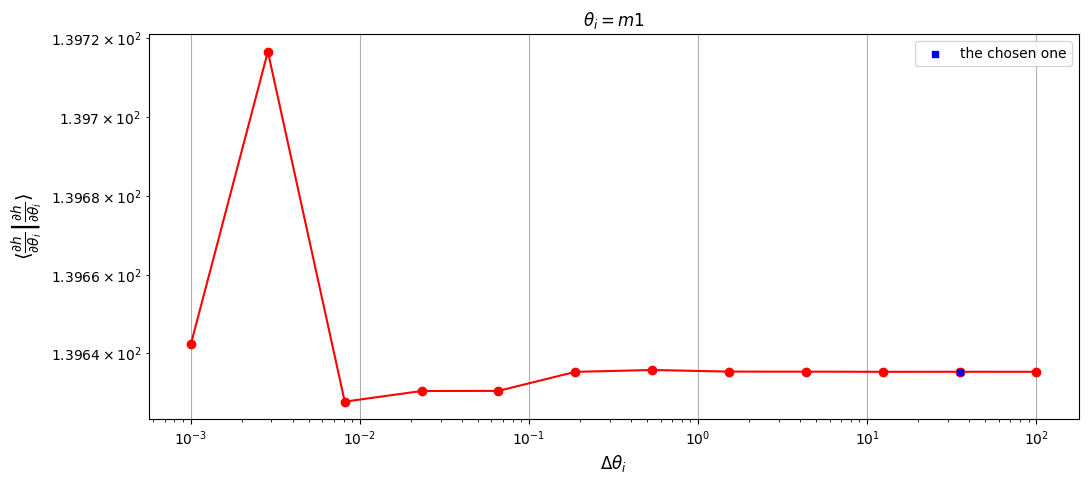

Gamma_ii for m2: 628743.2022521108
Gamma_ii for m2: 628743.2684465831
Gamma_ii for m2: 628743.4139121018
Gamma_ii for m2: 628743.2598420475
Gamma_ii for m2: 628743.504991564
Gamma_ii for m2: 628740.6804667374
Gamma_ii for m2: 628735.1639360319
Gamma_ii for m2: 628681.9133408797
Gamma_ii for m2: 628671.3766609797
Gamma_ii for m2: 628636.0628802521
Gamma_ii for m2: 629826.6675307713
Gamma_ii for m2: 629017.129147963
[np.float64(1.052806058917115e-07), np.float64(2.313591132383631e-07), np.float64(2.450444627208264e-07), np.float64(3.8990385515604155e-07), np.float64(4.492352593610233e-06), np.float64(8.774013323773187e-06), np.float64(8.470196775530914e-05), np.float64(1.6760234824084503e-05), np.float64(5.617523844522151e-05), np.float64(0.0018903687504801263), np.float64(0.0012869894082294566)]
0


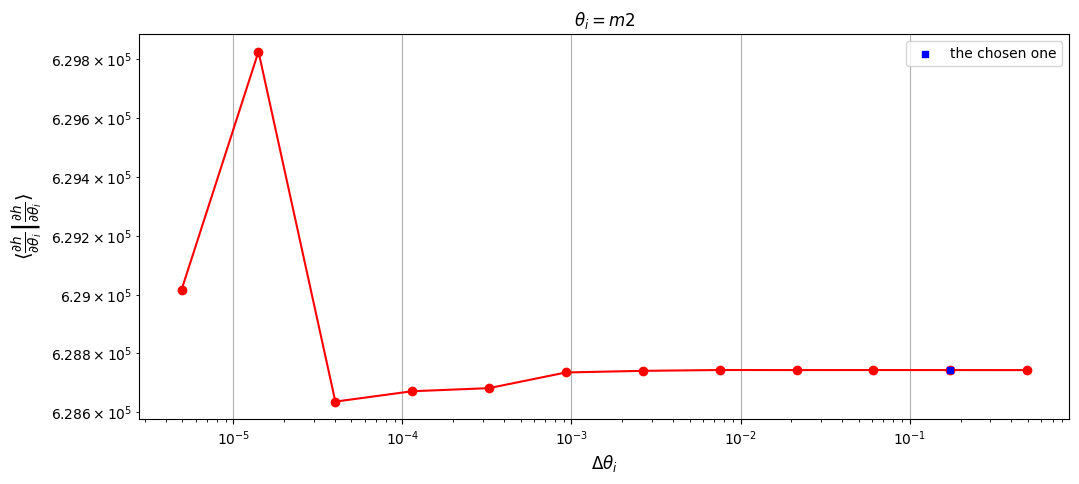

Gamma_ii for a: 268804778540.7527
Gamma_ii for a: 268804197178.4116
Gamma_ii for a: 268809951587.9132
Gamma_ii for a: 268803117305.4082
Gamma_ii for a: 268803103878.08658
Gamma_ii for a: 268800258599.81302
Gamma_ii for a: 268770158267.9221
Gamma_ii for a: 268868615203.13126
Gamma_ii for a: 269117755071.1919
Gamma_ii for a: 269400809572.0842
Gamma_ii for a: 268538383847.25363
Gamma_ii for a: 263816882018.57483
[np.float64(2.162772557859679e-06), np.float64(2.1406980908351806e-05), np.float64(2.542486327359039e-05), np.float64(4.995225661845672e-08), np.float64(1.0585102441421348e-05), np.float64(0.00011199283463949454), np.float64(0.000366189765714317), np.float64(0.0009257652583893302), np.float64(0.0010506817011496988), np.float64(0.003211554759788529), np.float64(0.017896890420933603)]
3


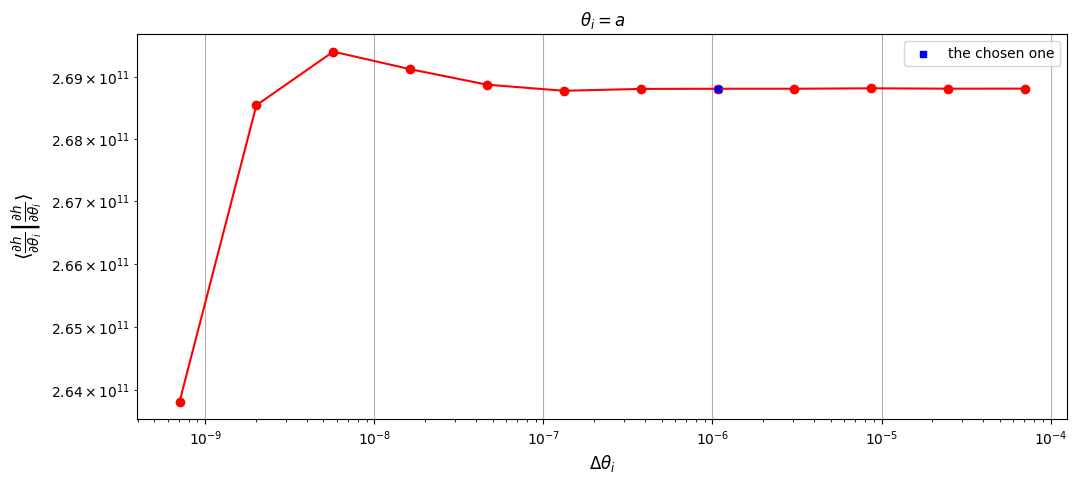

Gamma_ii for p0: 746880298494.4646
Gamma_ii for p0: 746880300441.2577
Gamma_ii for p0: 746880318443.4093
Gamma_ii for p0: 746880268894.103
Gamma_ii for p0: 746880392249.3225
Gamma_ii for p0: 746880583210.2357
Gamma_ii for p0: 746879298208.483
Gamma_ii for p0: 746884886435.2748
Gamma_ii for p0: 746879275393.3413
Gamma_ii for p0: 746712086618.5602
Gamma_ii for p0: 746905729446.7313
Gamma_ii for p0: 746543131721.7379
[np.float64(2.606566393129053e-09), np.float64(2.4103127591910347e-08), np.float64(6.634169938346496e-08), np.float64(1.651606077258534e-07), np.float64(2.556779724908917e-07), np.float64(1.7204945374277235e-06), np.float64(7.482045618059677e-06), np.float64(7.512649123269145e-06), np.float64(0.0002238999177557605), np.float64(0.00025926006527568485), np.float64(0.0004857023118773541)]
0


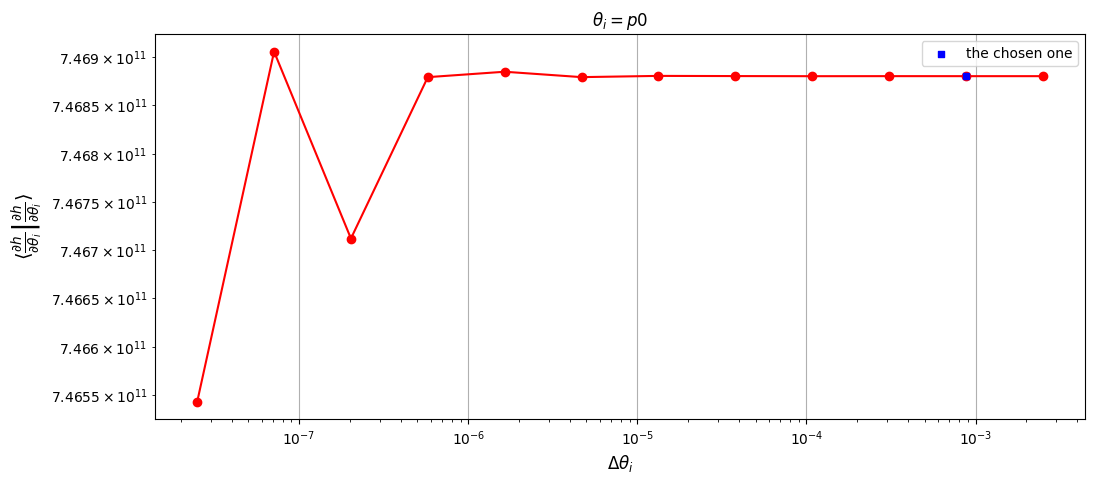

Gamma_ii for e0: 5794508850669.054
Gamma_ii for e0: 5794510142737.847
Gamma_ii for e0: 5794514176850.439
Gamma_ii for e0: 5794519017529.69
Gamma_ii for e0: 5794435031280.377
Gamma_ii for e0: 5794370818337.298
Gamma_ii for e0: 5794624437901.046
Gamma_ii for e0: 5793235726936.0625
Gamma_ii for e0: 5789291940954.494
Gamma_ii for e0: 5797779708012.171
Gamma_ii for e0: 5750555761471.046
Gamma_ii for e0: 5884708020550.109
[np.float64(2.2298153961954422e-07), np.float64(6.961951372713952e-07), np.float64(8.353893112322949e-07), np.float64(1.4494294760419188e-05), np.float64(1.1081952655823906e-05), np.float64(4.376807616541825e-05), np.float64(0.0002397124906425761), np.float64(0.0006812207817106799), np.float64(0.0014639685336693962), np.float64(0.008212066537555785), np.float64(0.0227967570541457)]
0


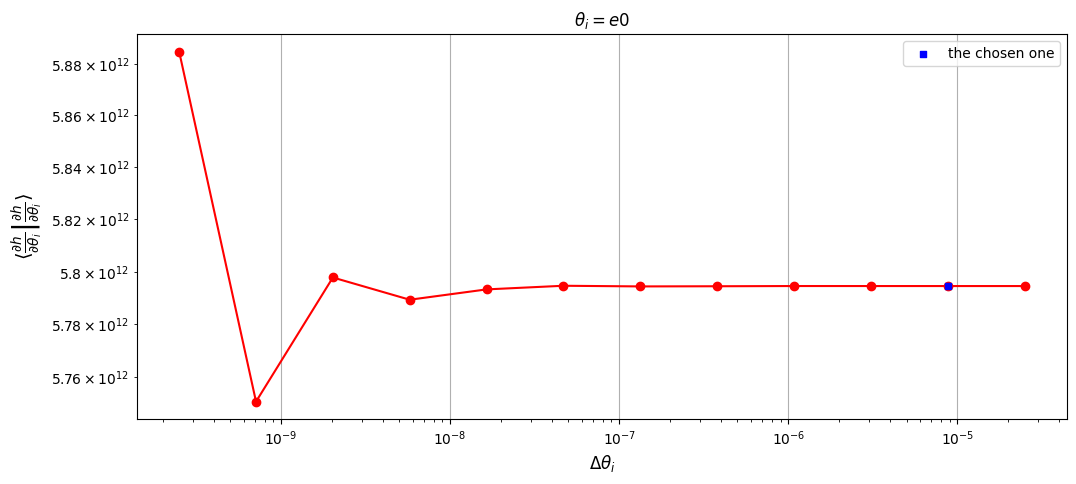

Gamma_ii for qS: 262984.8064778069
Gamma_ii for qS: 313454.91552571877
Gamma_ii for qS: 316880.67489211395
Gamma_ii for qS: 311297.6947432623
Gamma_ii for qS: 439442.5038348461
Gamma_ii for qS: 1269165.7796257457
Gamma_ii for qS: 7699702.667724843
Gamma_ii for qS: 2908251.5223173434
Gamma_ii for qS: 479281.02684732625
Gamma_ii for qS: 5383149.715314948
Gamma_ii for qS: 842371.699673144
Gamma_ii for qS: 598545.6045162503
[np.float64(0.1610123387705204), np.float64(0.010810881312221163), np.float64(0.017934537399822734), np.float64(0.2916076801249611), np.float64(0.6537548436230058), np.float64(0.8351669104125593), np.float64(1.6475367101637728), np.float64(5.067946276629389), np.float64(0.9109664318858193), np.float64(5.390468385160269), np.float64(0.40736427319344537)]
1
minimum relative error is greater than 1% for qS. Fisher may be unstable!


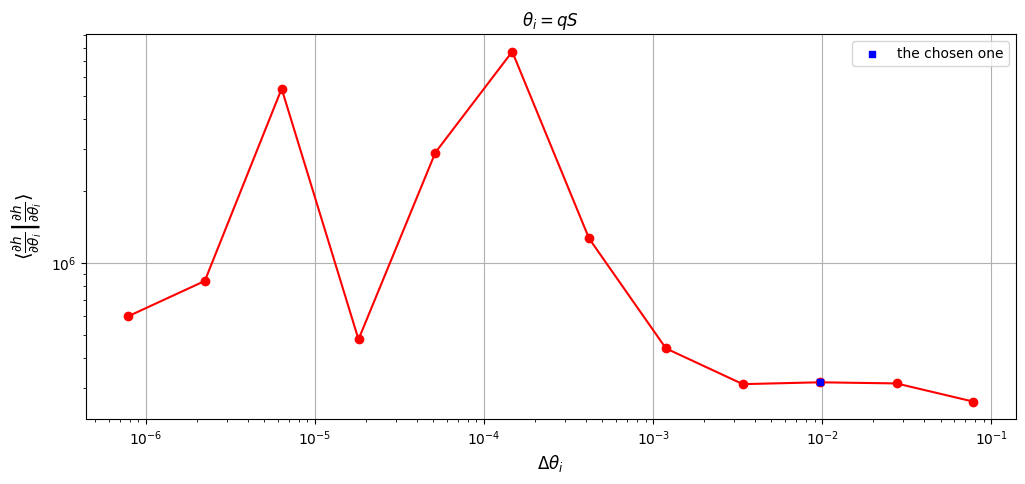

Gamma_ii for phiS: 333792.1336489146
Gamma_ii for phiS: 342848.5188125458
Gamma_ii for phiS: 345017.2557872409
Gamma_ii for phiS: 352032.7388170819
Gamma_ii for phiS: 411267.35758585954
Gamma_ii for phiS: 367140.4171400877
Gamma_ii for phiS: 344953.55210187443
Gamma_ii for phiS: 419316.9783593881
Gamma_ii for phiS: 487076.4380584119
Gamma_ii for phiS: 1106993.0648489876
Gamma_ii for phiS: 490862.81897891505
Gamma_ii for phiS: 418273.29502635344
[np.float64(0.026415121159041252), np.float64(0.006285879730121363), np.float64(0.019928496006975823), np.float64(0.14402946812138218), np.float64(0.12019090894297965), np.float64(0.06431841302408406), np.float64(0.17734418136004562), np.float64(0.13911463253925221), np.float64(0.5600004611367124), np.float64(1.255198442513403), np.float64(0.17354568129430323)]
1


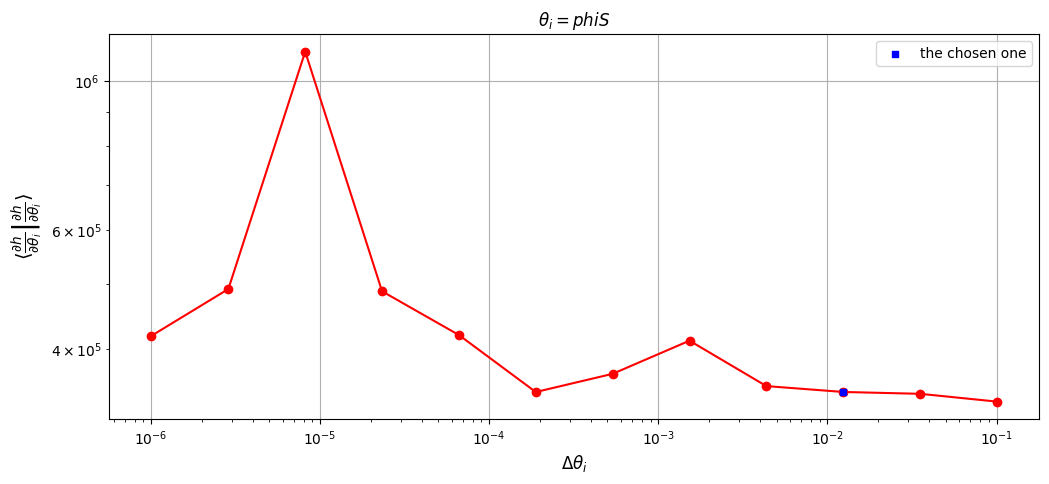

Gamma_ii for dev_1: 347047094.2601554
Gamma_ii for dev_1: 347047100.343437
Gamma_ii for dev_1: 347047107.89118475
Gamma_ii for dev_1: 347047116.3470593
Gamma_ii for dev_1: 347047116.77836263
Gamma_ii for dev_1: 347047102.272353
Gamma_ii for dev_1: 347046145.8502996
Gamma_ii for dev_1: 347058380.22190666
Gamma_ii for dev_1: 347046086.0192885
Gamma_ii for dev_1: 347050591.43237555
Gamma_ii for dev_1: 347074823.52892256
Gamma_ii for dev_1: 347007634.58232874
[np.float64(1.752869172575739e-08), np.float64(2.1748481861936067e-08), np.float64(2.436520623271025e-08), np.float64(1.2427803069479542e-09), np.float64(4.179838858566686e-08), np.float64(2.755893027001833e-06), np.float64(3.525162423463923e-05), np.float64(3.542527379922217e-05), np.float64(1.2982006653482073e-05), np.float64(6.981807640388599e-05), np.float64(0.00019362382811747688)]
3


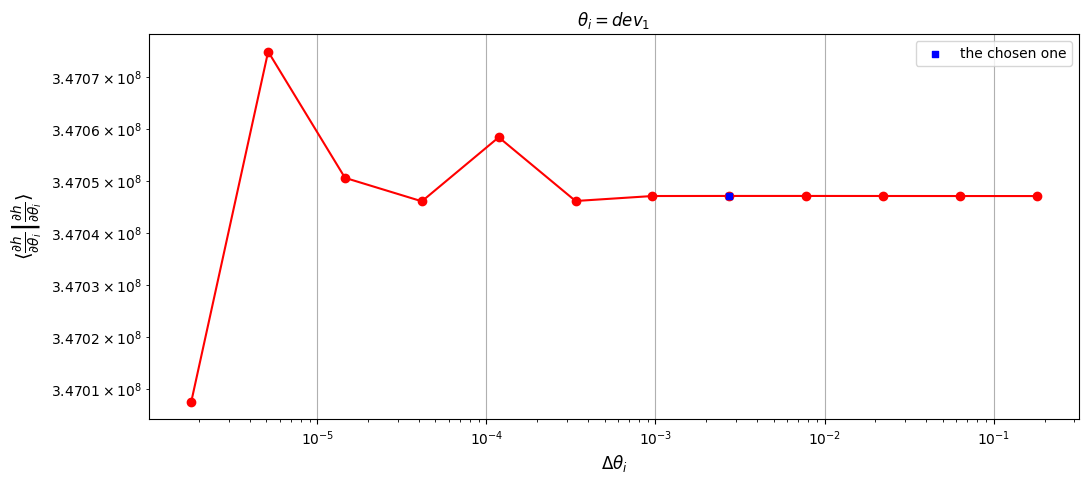

Gamma_ii for dev_2: 376981.65309794486
Gamma_ii for dev_2: 376981.5338525824
Gamma_ii for dev_2: 376981.58180802263
Gamma_ii for dev_2: 376980.92923467606
Gamma_ii for dev_2: 376980.3037246463
Gamma_ii for dev_2: 376985.3646936845
Gamma_ii for dev_2: 376971.20210864354
Gamma_ii for dev_2: 376956.31606791564
Gamma_ii for dev_2: 377057.0216953759
Gamma_ii for dev_2: 377535.2556776752
Gamma_ii for dev_2: 384355.459576427
Gamma_ii for dev_2: 378962.391332323
[np.float64(3.1631618994551176e-07), np.float64(1.2720897400587965e-07), np.float64(1.731051350243687e-06), np.float64(1.6592644857188226e-06), np.float64(1.3424842214600063e-05), np.float64(3.7569408383827114e-05), np.float64(3.9490094988133715e-05), np.float64(0.00026708328360378747), np.float64(0.0012667266834215274), np.float64(0.01774452197522553), np.float64(0.014231143689861947)]
1


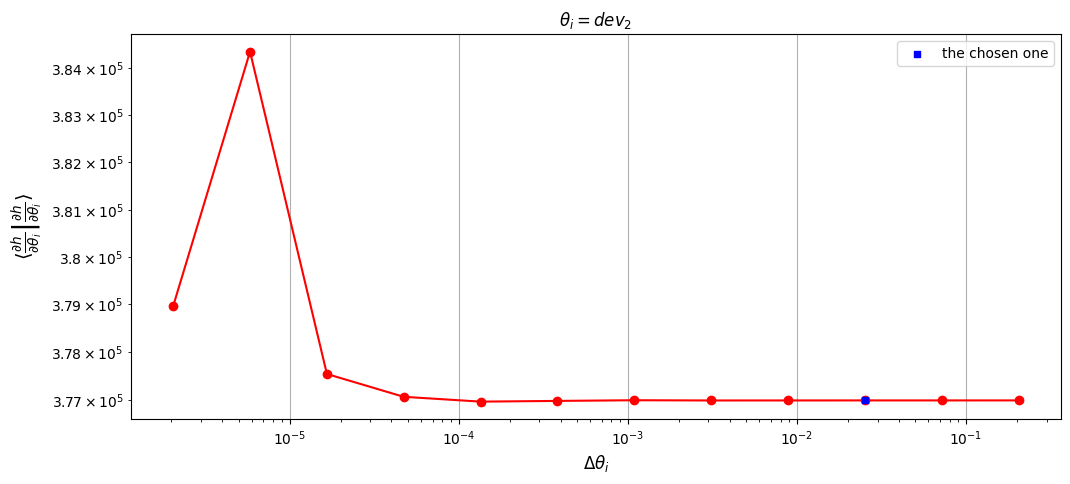

stable deltas: {'m1': 35.202159532861046, 'm2': 0.17381095577599753, 'a': 1.0716517989020214e-06, 'p0': 0.0008762414611034643, 'e0': 8.768394985114575e-06, 'qS': 0.009637305106177408, 'phiS': 0.01240268504920109, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev_1': 0.0027344064096222215, 'dev_2': 0.025249074163581436}
Time taken to compute stable deltas is 39.527912616729736 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 4.702809572219849 seconds


In [7]:
x_best_fit_0PA_dev = [1002570.1299598757, 4950.1983637714975, 0.7050753237616896, 24.955671106332613, 0.24972703426218926, 0.7817115297347373, 1.0060200227981309, 0.9601402852592612, 0.46323805827618125, 1.7990568266070708, 2.0480302502976233]

add_kwargs_0PA_dev = {'chi2': 0.95, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': x_best_fit_0PA_dev[9], 'dev_2': x_best_fit_0PA_dev[10]}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA_dev['chi2'],add_kwargs_0PA_dev['evolve_1PA'],
                    add_kwargs_0PA_dev['evolve_primary'],add_kwargs_0PA_dev['evolve_2PA'],
                      add_kwargs_0PA_dev['deviation_included'],add_kwargs_0PA_dev['dev_1'],add_kwargs_0PA_dev['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA_dev,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)

Covariance_fit_0PA_dev = fishinv(m1, Fisher, index_of_M=0)

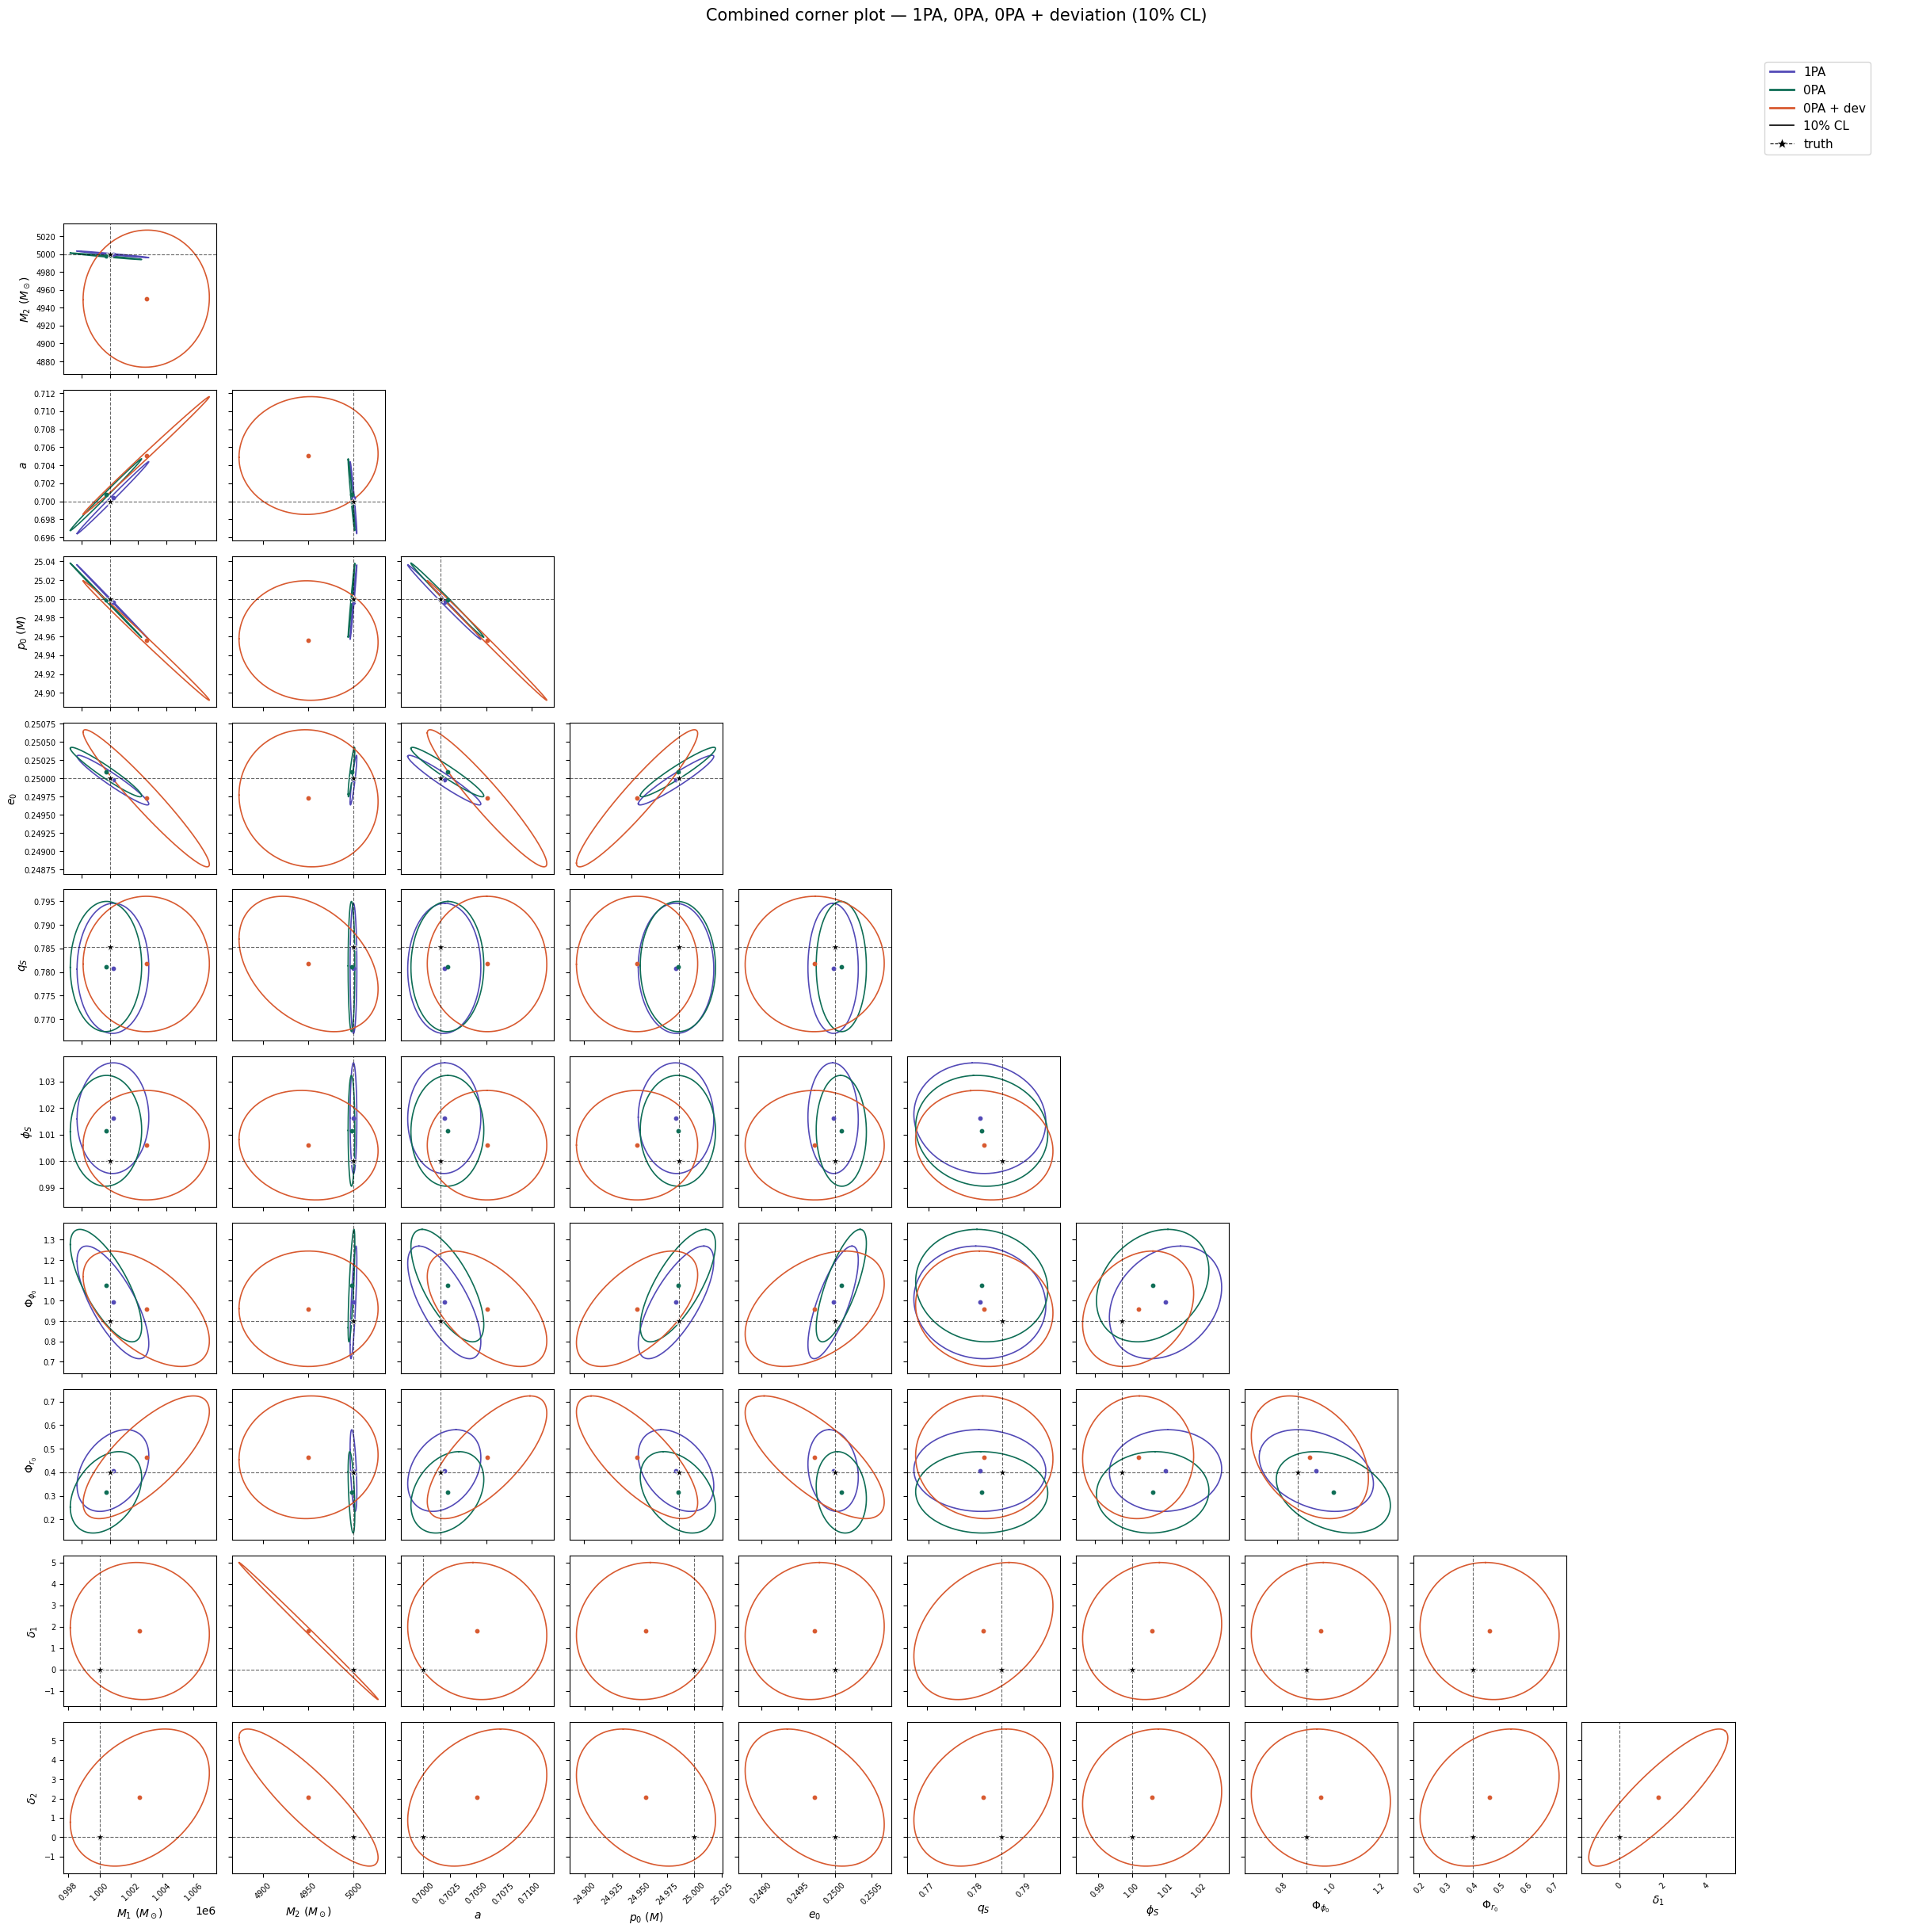

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
x_best_fit_1PA = np.array([1000221.8808939782, 4999.747773291232, 0.7003948786264647, 24.99655848906371,
                           0.2499766455289157, 0.7807865861253576, 1.0162072746890254, 0.9914252791409727, 0.4069748546993725])

x_best_fit_0PA = np.array([999731.181079391, 4997.5459544667, 0.7007325599970741, 24.998511054328947, 
                           0.25008760356709087,0.7811710116100292, 1.0114347544593056, 1.0739333709013787, 0.3145495163888312])

x_best_fit_0PA_dev = np.array([1002570.1299598757, 4950.1983637714975, 0.7050753237616896,
                                24.955671106332613, 0.24972703426218926, 0.7817115297347373,
                                  1.0060200227981309, 0.9601402852592612, 0.46323805827618125,
                                    1.7990568266070708, 2.0480302502976233])

# True injected parameters — order MUST match `labels` below.
signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 3,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
fits = [
    ('1PA',       x_best_fit_1PA,     Covariance_fit_1PA,     '#534AB7', 9),
    ('0PA',       x_best_fit_0PA,     Covariance_fit_0PA,     '#0F6E56', 9),
    ('0PA + dev', x_best_fit_0PA_dev, Covariance_fit_0PA_dev, '#D85A30', 11),
]

LEVELS         = (0.99,)
LEVEL_STYLES   = {0.99: '-'}
N_PARAMS_TOTAL = 11
TRUTH_COLOR    = '#000000'


# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]

    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])


# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS_TOTAL
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    if len(true_params) != D:
        raise ValueError(
            f"true_params has {len(true_params)} entries; expected {D} to match labels.")

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if j >= i:
                ax.axis('off')
                continue

            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)

            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)

            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])

            ax.tick_params(labelsize=7)

    legend_handles = [plt.Line2D([0], [0], color=color, lw=2, label=name)
                      for name, _, _, color, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='10% CL'))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))

    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)

    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + deviation (10% CL)',
                 fontsize=15, y=1.005)
    plt.tight_layout()
    plt.show()


combined_triangle_plot()

In [11]:
np.save('Covariance_fit_1PA_imri.npy',     Covariance_fit_1PA)
np.save('Covariance_fit_0PA_imri.npy',     Covariance_fit_0PA)
np.save('Covariance_fit_0PA_dev_imri.npy', Covariance_fit_0PA_dev)